In [ ]:
!pip install --upgrade --force-reinstall numpy pandas mendeleev pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

**:IMPORTING REQIURED MODULES**

In [ ]:
!pip install CBFV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 8.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition, Element
from mendeleev import element
from CBFV.composition import generate_features

***READING THE DATASET WITH HELP OF PANDAS MODULE***

In [ ]:
import os; df = pd.read_excel('../data/perovskites.xlsx' if os.path.exists('../data/perovskites.xlsx') else ('data/perovskites.xlsx' if os.path.exists('data/perovskites.xlsx') else 'https://raw.githubusercontent.com/Adhavan1801/PerovskiteML/main/data/perovskites.xlsx'))

In [ ]:
df

,formula,target
0,ReBTeGeO6,380.39
1,GeZnAl2O6,372.33
2,TcCaMnBeO6,359.72
3,ReSeAlCeO6,355.14
4,OsSeAlCeO6,352.48
...,...,...
583,Au2SeTeBr6,24.82
584,HgOsTeAgBr6,24.24
585,HgIrTeAgBr6,24.20
586,HgPtTeAgBr6,24.13


**GENERATING FEATURES WITH CBFV(Magpie)**

In [ ]:
X, y, formulas, skipped = generate_features(
    df,
    elem_prop='magpie',  # Choose a featurization scheme (e.g., 'oliynyk', 'magpie')
    drop_duplicates=True,  # Keep duplicates if any
    extend_features=True,  # Extend features or not
    sum_feat=True
   )

/usr/local/lib/python3.11/dist-packages/CBFV/composition.py:217: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df['formula'].value_counts()[0] > 1:


Duplicate formula(e) removed using default pandas function


Processing Input Data: 100%|██████████| 587/587 [00:00<00:00, 24858.96it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 587/587 [00:00<00:00, 10793.81it/s]

	Creating Pandas Objects...


In [ ]:
X

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_NValence,mode_NsUnfilled,mode_NpUnfilled,mode_NdUnfilled,mode_NfUnfilled,mode_NUnfilled,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber
0,212.00,817.00,493.25,8069.86,146.00,29.00,889.00,28.69,20.00,31.00,...,6.00,0.00,2.00,0.00,0.00,2.00,9.11,0.00,0.00,12.00
1,136.00,816.00,287.98,4099.82,148.00,26.00,880.00,27.52,20.00,28.00,...,6.00,0.00,2.00,0.00,0.00,2.00,9.11,0.00,0.00,12.00
2,140.00,701.00,298.02,6952.80,114.00,27.00,954.00,26.66,20.00,24.00,...,6.00,0.00,2.00,0.00,0.00,2.00,9.11,0.00,0.00,12.00
3,228.00,753.00,528.26,6286.27,135.00,31.00,992.00,27.82,20.00,29.00,...,6.00,0.00,2.00,0.00,0.00,2.00,9.11,0.00,0.00,12.00
4,229.00,756.00,532.28,6133.27,136.00,31.00,985.00,28.12,20.00,29.00,...,6.00,0.00,2.00,0.00,0.00,2.00,9.11,0.00,0.00,12.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,454.00,881.00,1079.92,5486.12,156.00,45.00,1250.00,27.49,18.00,38.00,...,17.00,0.00,1.00,0.00,0.00,1.00,29.48,1.46,0.00,64.00
583,465.00,853.00,1105.71,7092.71,149.00,46.00,1279.00,25.99,19.00,34.00,...,17.00,0.00,1.00,0.00,0.00,1.00,29.48,1.46,0.00,64.00
584,466.00,856.00,1107.70,6525.71,150.00,46.00,1276.00,25.99,19.00,34.00,...,17.00,0.00,1.00,0.00,0.00,1.00,29.48,1.46,0.00,64.00
585,467.00,859.00,1110.57,5828.11,151.00,46.00,1271.00,26.07,18.00,34.00,...,17.00,0.00,1.00,0.00,0.00,1.00,29.48,1.46,0.00,64.00


In [ ]:
y

,target
0,380.39
1,372.33
2,359.72
3,355.14
4,352.48
...,...
582,24.82
583,24.24
584,24.20
585,24.13


In [ ]:
formulas

,formula
0,ReBTeGeO6
1,GeZnAl2O6
2,TcCaMnBeO6
3,ReSeAlCeO6
4,OsSeAlCeO6
...,...
582,Au2SeTeBr6
583,HgOsTeAgBr6
584,HgIrTeAgBr6
585,HgPtTeAgBr6


In [ ]:
skipped

[]

**COUNTING THE FEATURES GIVEN BY CBFV(Magpie)**

In [ ]:
count=0
for feature in X.columns:
    count+=1
print("Total number of features extracted :",count)

Total number of features extracted : 154


#**FINDING THE COMPOSITION OF THE FORMULAS WITH HELP OF PYMATGEN**

In [ ]:
comp = [formula for formula in df['formula']]

#**FINDING GEOMENTRIC FACTORS WHICH ARE NOT IN CBFV**

In [ ]:
def featurize_pymatgen(formula):
  try:
        comp = Composition(formula)
        elements = list(comp.elements)
        print(elements)
        # Mean properties
        mean_electronegativity = np.mean([el.X for el in elements if el.X is not None])
        mean_ionic_radii = np.mean([max(el.ionic_radii.values(), default=0) for el in elements])
        num_elements = len(elements)

        if elements:
            # Indented block for the 'if' statement
            # Define A, B, and X site candidates
            a_elements = [el for el in elements if el.is_alkali or el.is_alkaline or el.is_lanthanoid]
            b_elements = [el for el in elements if el.is_transition_metal]
            x_site = next((el for el in elements if el.is_chalcogen or el.is_halogen), None)
            print(a_elements)
            #print(b_elements)
            #print(x_site)

            tolerance_factor, octahedral_factor, rho_A, rho_B = None, None, None, None

            # Case 1: A₂BB'X₆ (e.g., 2 A, 2 distinct B, 6 X)
            if len(a_elements) == 1 and len(b_elements) == 2 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
                a_site = a_elements[0]
                b_site, b_prime_site = b_elements[0], b_elements[1]
                r_A = max(a_site.ionic_radii.values(), default=0)
                r_B = max(b_site.ionic_radii.values(), default=0)
                r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
                r_X = max(x_site.ionic_radii.values(), default=0)

                if r_A > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                    avg_r_B = (r_B + r_B_prime) / 2
                    tolerance_factor = (r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                    octahedral_factor = avg_r_B / r_X
                    rho_A = (r_A - r_X) / (2 * r_X)
                    rho_B = (r_A - avg_r_B) / (2 * r_X)

            # Case 2: AA'B₂X₆ (e.g., 2 distinct A, 1 B type, 6 X)
            elif len(a_elements) == 2 and len(b_elements) == 1 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
                a_site, a_prime_site = a_elements[0], a_elements[1]
                b_site = b_elements[0]
                r_A = max(a_site.ionic_radii.values(), default=0)

                r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)

                r_B = max(b_site.ionic_radii.values(), default=0)
                r_X = max(x_site.ionic_radii.values(), default=0)

                if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_X > 0:
                    avg_r_A = (r_A + r_A_prime) / 2
                    tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (r_B + r_X))
                    octahedral_factor = r_B / r_X
                    rho_A = (avg_r_A - r_X) / (2 * r_X)
                    rho_B = (avg_r_A - r_B) / (2 * r_X)

            # Case 3: AA'BB'X₆ (e.g., 2 distinct A, 2 distinct B, 6 X)
            elif len(a_elements) == 2 and len(b_elements) == 2 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
                a_site, a_prime_site = a_elements[0], a_elements[1]
                b_site, b_prime_site = b_elements[0], b_elements[1]
                r_A = max(a_site.ionic_radii.values(), default=0)
                r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)
                r_B = max(b_site.ionic_radii.values(), default=0)
                r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
                r_X = max(x_site.ionic_radii.values(), default=0)

                if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                    avg_r_A = (r_A + r_A_prime) / 2
                    avg_r_B = (r_B + r_B_prime) / 2
                    tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                    octahedral_factor = avg_r_B / r_X
                    rho_A = (avg_r_A - r_X) / (2 * r_X)
                    rho_B = (avg_r_A - avg_r_B) / (2 * r_X)

        # Return results
        return {

            "mean_electronegativity": mean_electronegativity,
            "mean_ionic_radii": mean_ionic_radii,
            "num_elements": num_elements,
            "tolerance_factor": tolerance_factor,
            "octahedral_factor": octahedral_factor,
            "mismatch_factor_A": rho_A,
            "mismatch_factor_B": rho_B
        }

  except Exception as e:
        print(f"Error featurizing {formula}: {e}")
        return {

            "mean_electronegativity": None,
            "mean_ionic_radii": None,
            "num_elements": None,
            "tolerance_factor": None,
            "octahedral_factor": None,
            "mismatch_factor_A": None,
            "mismatch_factor_B": None
        }

In [ ]:

mean_electronegativity=[]
mean_ionic_radii=[]
tolerance_factor_d=[]
octahedral_factor=[]
mismatch_factor_A=[]
mismatch_factor_B=[]
print(formulas[0])
print(featurize_pymatgen(formulas[0]))
#for i in range(len(formulas)):
 # features=featurize_pymatgen(formulas[i])

  #mean_electronegativity.append(features['mean_electronegativity'])
  #mean_ionic_radii.append(features['mean_ionic_radii'])
  #tolerance_factor_d.append(features['tolerance_factor'])
  #octahedral_factor.append(features['octahedral_factor'])
  #mismatch_factor_A.append(features['mismatch_factor_A'])
  #mismatch_factor_B.append(features['mismatch_factor_B'])

ReBTeGeO6
[Element Re, Element B, Element Te, Element Ge, Element O]
[]
{'mean_electronegativity': 2.298, 'mean_ionic_radii': 1.076, 'num_elements': 5, 'tolerance_factor': None, 'octahedral_factor': None, 'mismatch_factor_A': None, 'mismatch_factor_B': None}


In [ ]:
extra_features=pd.DataFrame( {

            "mean_electronegativity": mean_electronegativity,
            "mean_ionic_radii": mean_ionic_radii,
            "tolerance_factor": tolerance_factor_d,
            "octahedral_factor": octahedral_factor,
            "mismatch_factor_A": mismatch_factor_A,
            "mismatch_factor_B": mismatch_factor_B
        })

In [ ]:
extra_features

,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B


In [ ]:
x=pd.concat([X,extra_features],axis=1)

In [ ]:
x

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,212.00,817.00,493.25,8069.86,146.00,29.00,889.00,28.69,20.00,31.00,...,9.11,0.00,0.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN
1,136.00,816.00,287.98,4099.82,148.00,26.00,880.00,27.52,20.00,28.00,...,9.11,0.00,0.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN
2,140.00,701.00,298.02,6952.80,114.00,27.00,954.00,26.66,20.00,24.00,...,9.11,0.00,0.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN
3,228.00,753.00,528.26,6286.27,135.00,31.00,992.00,27.82,20.00,29.00,...,9.11,0.00,0.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN
4,229.00,756.00,532.28,6133.27,136.00,31.00,985.00,28.12,20.00,29.00,...,9.11,0.00,0.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,454.00,881.00,1079.92,5486.12,156.00,45.00,1250.00,27.49,18.00,38.00,...,29.48,1.46,0.00,64.00,NaN,NaN,NaN,NaN,NaN,NaN
583,465.00,853.00,1105.71,7092.71,149.00,46.00,1279.00,25.99,19.00,34.00,...,29.48,1.46,0.00,64.00,NaN,NaN,NaN,NaN,NaN,NaN
584,466.00,856.00,1107.70,6525.71,150.00,46.00,1276.00,25.99,19.00,34.00,...,29.48,1.46,0.00,64.00,NaN,NaN,NaN,NaN,NaN,NaN
585,467.00,859.00,1110.57,5828.11,151.00,46.00,1271.00,26.07,18.00,34.00,...,29.48,1.46,0.00,64.00,NaN,NaN,NaN,NaN,NaN,NaN


#**IMPORTING MODULES FOR PREDICTION**

In [ ]:
!pip install lazypredict
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.6 MB/s eta 0:00:00


# **SCALING THE DATASET**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)

In [ ]:

X_scaled

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,-0.89,0.03,-0.82,1.18,0.27,-1.19,-1.37,0.96,0.73,-0.63,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.80,0.01,-1.83,-1.44,0.50,-1.71,-1.43,0.27,0.73,-1.42,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.76,-2.52,-1.78,0.44,-3.30,-1.53,-0.96,-0.23,0.73,-2.48,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.70,-1.37,-0.64,0.00,-0.96,-0.84,-0.72,0.45,0.73,-1.15,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.69,-1.31,-0.62,-0.10,-0.84,-0.84,-0.77,0.62,0.73,-1.15,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,2.01,1.43,2.08,-0.52,1.39,1.58,0.89,0.25,-1.68,1.22,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
583,2.14,0.82,2.21,0.54,0.61,1.75,1.08,-0.63,-0.47,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
584,2.16,0.89,2.22,0.16,0.72,1.75,1.06,-0.63,-0.47,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
585,2.17,0.95,2.23,-0.30,0.83,1.75,1.03,-0.58,-1.68,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN


#**SPLITING THE DATASET FOR TRAIN AND TEST**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, random_state=42)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5708
[LightGBM] [Info] Number of data points in the train set: 469, number of used features: 138
[LightGBM] [Info] Start training from score 111.309147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
Lars,7661543343974297310763585665175125162912120832.00,-2815780887101664877787069955074165722125959168.00,3232059917559073425326080.00,0.22
KernelRidge,10.50,-2.49,113.83,0.10
GaussianProcessRegressor,9.59,-2.16,108.22,0.28
RANSACRegressor,9.53,-2.14,107.86,1.12
QuantileRegressor,3.88,-0.06,62.68,1.49
DummyRegressor,3.72,-0.00,60.91,0.02
LarsCV,3.65,0.03,60.14,0.91
NuSVR,3.06,0.24,52.97,0.05
SVR,3.05,0.25,52.86,0.06


# **1.XGBOOST MODEL**

In [ ]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=xgb_model, n_features_to_select=20)
rfe.fit(X_scaled, y)
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)

Selected features: Index(['sum_AtomicWeight', 'sum_Column', 'sum_NValence', 'sum_NpUnfilled',
       'sum_NUnfilled', 'dev_Column', 'dev_Row', 'dev_NUnfilled',
       'range_MeltingT', 'range_CovalentRadius', 'range_NpUnfilled',
       'range_GSvolume_pa', 'range_SpaceGroupNumber', 'max_Number',
       'max_CovalentRadius', 'max_NValence', 'max_NUnfilled', 'min_NUnfilled',
       'mean_ionic_radii', 'octahedral_factor'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print results
print("\nXGBoost Regressor Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


XGBoost Regressor Performance:
R² Score: 0.7861
Mean Absolute Error (MAE): 14.6647
Root Mean Squared Error (RMSE): 28.1722


# **2.LGBM Regressor**





In [ ]:
# Import required libraries
from lightgbm import LGBMRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Assuming X_scaled and y are already defined from your earlier code
# X_scaled: Your scaled features after CBFV and geometric factors
# y: Your target variable

# Define LGBM Regressor with RFE
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=lgbm_model, n_features_to_select=20)  # Select top 20 features
rfe.fit(X_scaled, y)

# Get selected features
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

# Train the LGBM model
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42)
lgbm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = lgbm_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print results
print("\nLGBM Regressor Performance (Baseline):")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

# **3.Random Forest Model**

In [ ]:
!pip install scikit-optimize
from skopt import BayesSearchCV # Import BayesSearchCV from skopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.8 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
# Define RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=20)
rfe.fit(X_scaled, y)
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)



Selected features: Index(['sum_AtomicWeight', 'sum_NdValence', 'sum_NValence', 'sum_NUnfilled',
       'avg_Number', 'avg_CovalentRadius', 'dev_MeltingT', 'dev_Column',
       'dev_NValence', 'dev_NpUnfilled', 'dev_SpaceGroupNumber',
       'range_MeltingT', 'range_CovalentRadius', 'range_GSvolume_pa',
       'max_Number', 'max_MeltingT', 'max_NValence', 'min_Number',
       'min_AtomicWeight', 'min_GSvolume_pa'],
      dtype='object')


In [ ]:
# Train Test Split the data
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
Y_pred = rf_model.predict(X_test)

In [ ]:
R2_score = r2_score(y_test, Y_pred)
MAE = mean_absolute_error(y_test, Y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, Y_pred))

#Print Results
print("\nRandom Forest Regressor Performance:")
print(f"R² Score: {R2_score:.4f}")
print(f"Mean Absolute Error (MAE): {MAE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")


Random Forest Regressor Performance:
R² Score: 0.7516
Mean Absolute Error (MAE): 16.3240
Root Mean Squared Error (RMSE): 30.3577


In [ ]:
# Step 7: Feature selection with RFE
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=20)
rfe.fit(X_scaled, y)
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)

Selected features: Index(['sum_AtomicWeight', 'sum_NdValence', 'sum_NValence', 'sum_NUnfilled',
       'avg_Number', 'avg_CovalentRadius', 'dev_MeltingT', 'dev_Column',
       'dev_NValence', 'dev_NpUnfilled', 'dev_SpaceGroupNumber',
       'range_MeltingT', 'range_CovalentRadius', 'range_GSvolume_pa',
       'max_Number', 'max_MeltingT', 'max_NValence', 'min_Number',
       'min_AtomicWeight', 'min_GSvolume_pa'],
      dtype='object')


In [ ]:
# Step 8: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

In [ ]:
# Step 9: Run LazyPredict to compare multiple models
print("\nRunning LazyPredict to compare regression models...")
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)
print("\nLazyPredict Model Performance:")
print(models)


Running LazyPredict to compare regression models...


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 469, number of used features: 20
[LightGBM] [Info] Start training from score 111.309147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
# Step 10: Evaluate LazyPredict's Random Forest explicitly
lazy_rf = RandomForestRegressor(n_estimators=100, random_state=42)  # Default settings
lazy_rf.fit(X_train, y_train)
Y_pred_lazy = lazy_rf.predict(X_test)
R2_score_lazy = r2_score(y_test, Y_pred_lazy)
MAE_lazy = mean_absolute_error(y_test, Y_pred_lazy)
RMSE_lazy = np.sqrt(mean_squared_error(y_test, Y_pred_lazy))
R2_score_lazy_train = r2_score(y_train, lazy_rf.predict(X_train))

print("\nLazyPredict Random Forest Regressor Performance (Default Settings):")
print(f"Train R² Score: {R2_score_lazy_train:.4f}")
print(f"Test R² Score: {R2_score_lazy:.4f}")
print(f"Mean Absolute Error (MAE): {MAE_lazy:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE_lazy:.4f}")


LazyPredict Random Forest Regressor Performance (Default Settings):
Train R² Score: 0.9752
Test R² Score: 0.7516
Mean Absolute Error (MAE): 16.3240
Root Mean Squared Error (RMSE): 30.3577


In [ ]:
# Step 11: Bayesian Optimization with Random Forest (Expanded Search Space)
param_space = {
    'n_estimators': (50, 1000),           # Wider range for number of trees
    'max_depth': (5, 100),               # Changed: Provide a finite upper bound for max_depth
    'min_samples_split': (2, 20),         # Wider range for splitting
    'min_samples_leaf': (1, 10),          # Wider range for leaf size
    'max_features': (0.1, 1.0)            # Fraction of features to consider
}

bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=param_space,
    n_iter=100,             # Increase iterations for better exploration
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Optimize for R² score
    n_jobs=-1,              # Use all available CPU cores
    random_state=42,
    verbose=1
)

# Fit the model
bayes_search.fit(X_train, y_train)

# Get the best model and parameters
best_rf = bayes_search.best_estimator_
print("Best parameters:", bayes_search.best_params_)

# Step 12: Predict and evaluate the optimized Random Forest
Y_pred = best_rf.predict(X_test)
R2_score = r2_score(y_test, Y_pred)
MAE = mean_absolute_error(y_test, Y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, Y_pred))
R2_score_train = r2_score(y_train, best_rf.predict(X_train))

print("\nOptimized Random Forest Regressor Performance (Bayesian Optimization):")
print(f"Train R² Score: {R2_score_train:.4f}")
print(f"Test R² Score: {R2_score:.4f}")
print(f"Mean Absolute Error (MAE): {MAE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

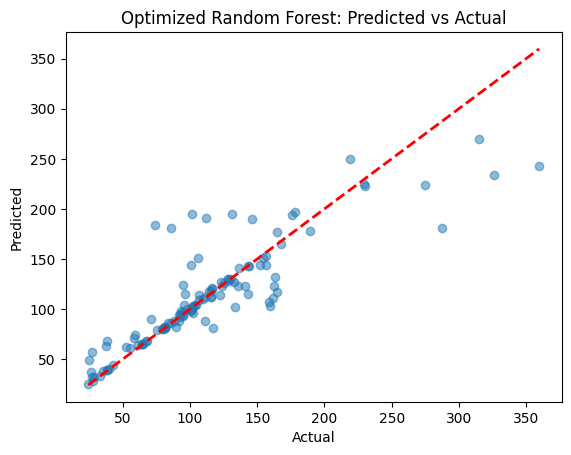


Feature Importance (Optimized Random Forest):
                 Feature  Importance
11        range_MeltingT        0.12
13     range_GSvolume_pa        0.09
6           dev_MeltingT        0.08
2           sum_NValence        0.07
19       min_GSvolume_pa        0.07
17            min_Number        0.06
18      min_AtomicWeight        0.06
0       sum_AtomicWeight        0.05
15          max_MeltingT        0.05
8           dev_NValence        0.05
1          sum_NdValence        0.04
12  range_CovalentRadius        0.04
3          sum_NUnfilled        0.04
10  dev_SpaceGroupNumber        0.03
4             avg_Number        0.03
16          max_NValence        0.03
5     avg_CovalentRadius        0.03
14            max_Number        0.03
7             dev_Column        0.02
9         dev_NpUnfilled        0.01


In [ ]:
# Step 13: Visualize predicted vs actual values for Optimized Random Forest
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib

plt.scatter(y_test, Y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Optimized Random Forest: Predicted vs Actual')
plt.show()

# Step 14: Feature importance for Optimized Random Forest
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_rfe.columns, 'Importance': importances})
print("\nFeature Importance (Optimized Random Forest):")
print(feature_importance_df.sort_values('Importance', ascending=False))

# **4.EXTRA TREES REGRESSOR**

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split

In [ ]:
X_scaled

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,-0.89,0.03,-0.82,1.18,0.27,-1.19,-1.37,0.96,0.73,-0.63,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.80,0.01,-1.83,-1.44,0.50,-1.71,-1.43,0.27,0.73,-1.42,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.76,-2.52,-1.78,0.44,-3.30,-1.53,-0.96,-0.23,0.73,-2.48,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.70,-1.37,-0.64,0.00,-0.96,-0.84,-0.72,0.45,0.73,-1.15,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.69,-1.31,-0.62,-0.10,-0.84,-0.84,-0.77,0.62,0.73,-1.15,...,-1.08,-1.09,0.00,-1.11,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,2.01,1.43,2.08,-0.52,1.39,1.58,0.89,0.25,-1.68,1.22,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
583,2.14,0.82,2.21,0.54,0.61,1.75,1.08,-0.63,-0.47,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
584,2.16,0.89,2.22,0.16,0.72,1.75,1.06,-0.63,-0.47,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN
585,2.17,0.95,2.23,-0.30,0.83,1.75,1.03,-0.58,-1.68,0.17,...,1.09,0.36,0.00,0.91,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
rf_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=20)
rfe.fit(X_scaled, y)
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)

Selected features: Index(['sum_NdValence', 'sum_NValence', 'dev_MeltingT', 'dev_Row',
       'dev_NpUnfilled', 'dev_NdUnfilled', 'dev_SpaceGroupNumber',
       'range_MeltingT', 'range_NdUnfilled', 'max_Number', 'max_MeltingT',
       'max_NfValence', 'max_NValence', 'max_GSbandgap', 'min_Number',
       'min_AtomicWeight', 'min_Row', 'min_CovalentRadius', 'min_NUnfilled',
       'mode_SpaceGroupNumber'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
Y_pred = rf_model.predict(X_test)

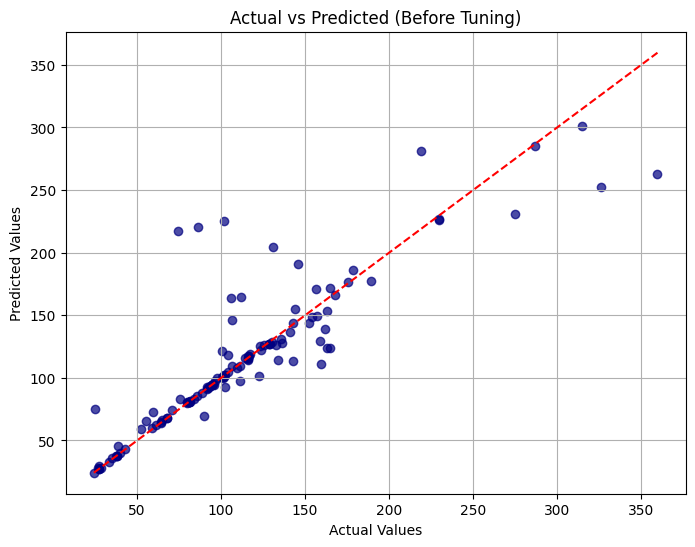


Extra trees Regressor performance :
R² Score: 0.7631
Mean Absolute Error (MAE): 13.1927
Root Mean Squared Error (RMSE): 29.6471


In [ ]:
R2_score = r2_score(y_test, Y_pred)
MAE = mean_absolute_error(y_test, Y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, Y_pred))

#Print Results
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, Y_pred, alpha=0.7, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Before Tuning)")
plt.grid(True)
plt.show()
print("\nExtra trees Regressor performance :")
print(f"R² Score: {R2_score:.4f}")
print(f"Mean Absolute Error (MAE): {MAE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")


In [ ]:
!pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.5 MB/s eta 0:00:00


Fitting 5 folds for each of 50 candidates, totalling 250 fits


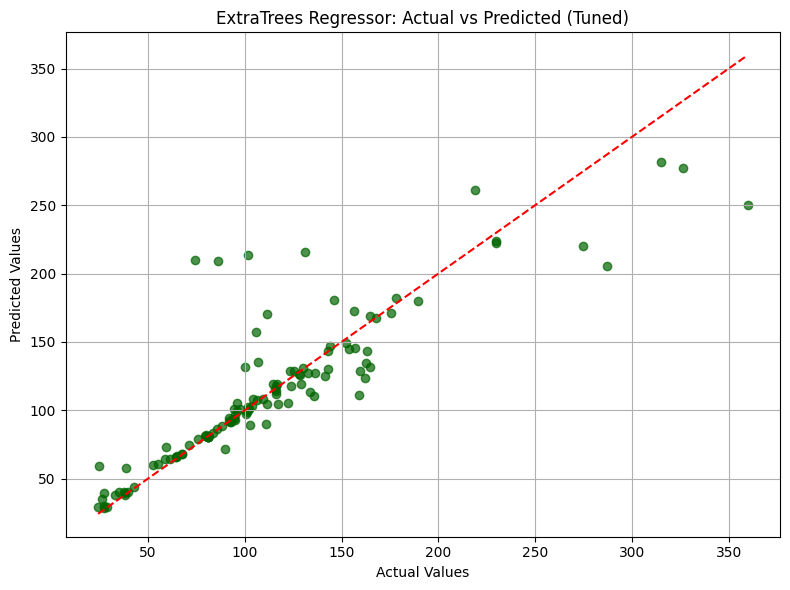


✅ Tuned ExtraTrees Regressor Performance:
Best Parameters: {'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 643}
R² Score: 0.7658
MAE: 14.6575
RMSE: 29.4738


In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(300, 700),
    'max_depth': [None, 30, 40, 50, 60],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# Step 5: RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# Step 6: Evaluate Tuned Model
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("ExtraTrees Regressor: Actual vs Predicted (Tuned)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Tuned ExtraTrees Regressor Performance:")
print("Best Parameters:", random_search.best_params_)
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Step 7: Plot - Actual vs Predicted



# **5.GRADIENT BOOSTING REGRESSOR**


Duplicate formula(e) removed using default pandas function


Processing Input Data: 100%|██████████| 587/587 [00:00<00:00, 8040.02it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 587/587 [00:00<00:00, 4983.71it/s]


	Creating Pandas Objects...
Selected features: Index(['sum_Number', 'sum_NValence', 'sum_NpUnfilled', 'avg_AtomicWeight',
       'avg_NValence', 'avg_NUnfilled', 'avg_SpaceGroupNumber',
       'dev_AtomicWeight', 'dev_Column', 'dev_NpUnfilled', 'dev_NdUnfilled',
       'range_MeltingT', 'range_CovalentRadius', 'range_NValence',
       'max_MendeleevNumber', 'max_AtomicWeight', 'max_MeltingT',
       'max_NValence', 'min_GSvolume_pa', 'mean_ionic_radii'],
      dtype='object')

Running LazyPredict to compare regression models...


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1258
[LightGBM] [Info] Number of data points in the train set: 469, number of used features: 20
[LightGBM] [Info] Start training from score 111.309147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

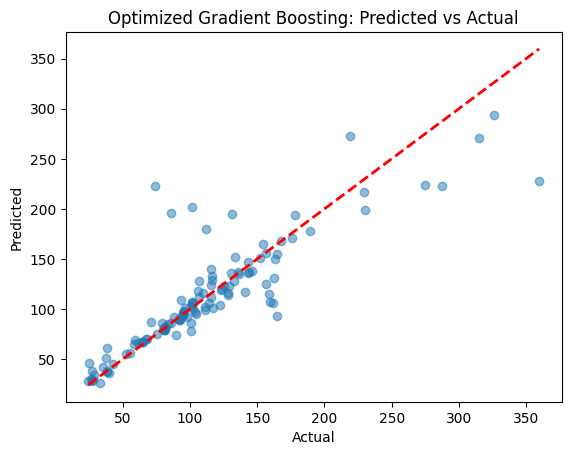


Feature Importance (Optimized Gradient Boosting):
                 Feature  Importance
1           sum_NValence        0.12
19      mean_ionic_radii        0.11
18       min_GSvolume_pa        0.10
11        range_MeltingT        0.09
3       avg_AtomicWeight        0.09
16          max_MeltingT        0.08
12  range_CovalentRadius        0.07
14   max_MendeleevNumber        0.05
6   avg_SpaceGroupNumber        0.04
8             dev_Column        0.03
17          max_NValence        0.03
15      max_AtomicWeight        0.03
4           avg_NValence        0.03
0             sum_Number        0.03
5          avg_NUnfilled        0.02
7       dev_AtomicWeight        0.02
10        dev_NdUnfilled        0.02
13        range_NValence        0.01
2         sum_NpUnfilled        0.01
9         dev_NpUnfilled        0.01


In [ ]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition, Element
from CBFV.composition import generate_features
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from lazypredict.Supervised import LazyRegressor
import matplotlib.pyplot as plt

# Step 3: Load the dataset
import os; df = pd.read_excel('../data/perovskites.xlsx' if os.path.exists('../data/perovskites.xlsx') else ('data/perovskites.xlsx' if os.path.exists('data/perovskites.xlsx') else 'https://raw.githubusercontent.com/Adhavan1801/PerovskiteML/main/data/perovskites.xlsx'))

# Step 4: Generate features with CBFV (Magpie)
X, y, formulas, skipped = generate_features(
    df,
    elem_prop='magpie',
    drop_duplicates=True,
    extend_features=True,
    sum_feat=True
)

# Step 5: Define a function to calculate geometric factors
def featurize_pymatgen(formula):
    try:
        comp = Composition(formula)
        elements = list(comp.elements)
        mean_electronegativity = np.mean([el.X for el in elements if el.X is not None])
        mean_ionic_radii = np.mean([max(el.ionic_radii.values(), default=0) for el in elements])
        num_elements = len(elements)
        a_elements = [el for el in elements if el.is_alkali or el.is_alkaline or el.is_lanthanoid]
        b_elements = [el for el in elements if el.is_transition_metal]
        x_site = next((el for el in elements if el.is_chalcogen or el.is_halogen), None)
        tolerance_factor, octahedral_factor, rho_A, rho_B = None, None, None, None

        if len(a_elements) == 1 and len(b_elements) == 2 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
            a_site = a_elements[0]
            b_site, b_prime_site = b_elements[0], b_elements[1]
            r_A = max(a_site.ionic_radii.values(), default=0)
            r_B = max(b_site.ionic_radii.values(), default=0)
            r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
            r_X = max(x_site.ionic_radii.values(), default=0)
            if r_A > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                avg_r_B = (r_B + r_B_prime) / 2
                tolerance_factor = (r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                octahedral_factor = avg_r_B / r_X
                rho_A = (r_A - r_X) / (2 * r_X)
                rho_B = (r_A - avg_r_B) / (2 * r_X)
        elif len(a_elements) == 2 and len(b_elements) == 1 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
            a_site, a_prime_site = a_elements[0], a_elements[1]
            b_site = b_elements[0]
            r_A = max(a_site.ionic_radii.values(), default=0)
            r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)
            r_B = max(b_site.ionic_radii.values(), default=0)
            r_X = max(x_site.ionic_radii.values(), default=0)
            if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_X > 0:
                avg_r_A = (r_A + r_A_prime) / 2
                tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (r_B + r_X))
                octahedral_factor = r_B / r_X
                rho_A = (avg_r_A - r_X) / (2 * r_X)
                rho_B = (avg_r_A - r_B) / (2 * r_X)
        elif len(a_elements) == 2 and len(b_elements) == 2 and x_site and comp.get_el_amt_dict()[x_site.symbol] == 6:
            a_site, a_prime_site = a_elements[0], a_elements[1]
            b_site, b_prime_site = b_elements[0], b_elements[1]
            r_A = max(a_site.ionic_radii.values(), default=0)
            r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)
            r_B = max(b_site.ionic_radii.values(), default=0)
            r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
            r_X = max(x_site.ionic_radii.values(), default=0)
            if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                avg_r_A = (r_A + r_A_prime) / 2
                avg_r_B = (r_B + r_B_prime) / 2
                tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                octahedral_factor = avg_r_B / r_X
                rho_A = (avg_r_A - r_X) / (2 * r_X)
                rho_B = (avg_r_A - avg_r_B) / (2 * r_X)
        return {
            "mean_electronegativity": mean_electronegativity,
            "mean_ionic_radii": mean_ionic_radii,
            "num_elements": num_elements,
            "tolerance_factor": tolerance_factor,
            "octahedral_factor": octahedral_factor,
            "mismatch_factor_A": rho_A,
            "mismatch_factor_B": rho_B
        }
    except Exception as e:
        print(f"Error featurizing {formula}: {e}")
        return {
            "mean_electronegativity": None,
            "mean_ionic_radii": None,
            "num_elements": None,
            "tolerance_factor": None,
            "octahedral_factor": None,
            "mismatch_factor_A": None,
            "mismatch_factor_B": None
        }

# Calculate geometric factors
mean_electronegativity = []
mean_ionic_radii = []
tolerance_factor_d = []
octahedral_factor = []
mismatch_factor_A = []
mismatch_factor_B = []
for formula in formulas:
    features = featurize_pymatgen(formula)
    mean_electronegativity.append(features['mean_electronegativity'])
    mean_ionic_radii.append(features['mean_ionic_radii'])
    tolerance_factor_d.append(features['tolerance_factor'])
    octahedral_factor.append(features['octahedral_factor'])
    mismatch_factor_A.append(features['mismatch_factor_A'])
    mismatch_factor_B.append(features['mismatch_factor_B'])

# Create DataFrame for extra features
X_combined = pd.concat([X, extra_features], axis=1)

# ***Impute NaN values using SimpleImputer***
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Replace NaN with the mean of the column
X_combined_imputed = imputer.fit_transform(X_combined)
X_combined = pd.DataFrame(X_combined_imputed, columns=X_combined.columns)


# Step 6: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)  # Use the imputed data for scaling
X_scaled = pd.DataFrame(X_scaled, columns=X_combined.columns)


# Step 7: Feature selection with RFE
# Use GradientBoostingRegressor for RFE to align with the main model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=gb_model, n_features_to_select=20)
rfe.fit(X_scaled, y)
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]
print("Selected features:", selected_features)

# Step 8: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

# Step 9: Run LazyPredict
print("\nRunning LazyPredict to compare regression models...")
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)
print("\nLazyPredict Model Performance:")
print(models)

# Step 10: Evaluate LazyPredict's Gradient Boosting Regressor explicitly
lazy_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)  # Default settings
lazy_gb.fit(X_train, y_train)
Y_pred_lazy = lazy_gb.predict(X_test)
R2_score_lazy = r2_score(y_test, Y_pred_lazy)
MAE_lazy = mean_absolute_error(y_test, Y_pred_lazy)
RMSE_lazy = np.sqrt(mean_squared_error(y_test, Y_pred_lazy))
R2_score_lazy_train = r2_score(y_train, lazy_gb.predict(X_train))

print("\nLazyPredict Gradient Boosting Regressor Performance (Default Settings):")
print(f"Train R² Score: {R2_score_lazy_train:.4f}")
print(f"Test R² Score: {R2_score_lazy:.4f}")
print(f"Mean Absolute Error (MAE): {MAE_lazy:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE_lazy:.4f}")

# Step 11: GridSearchCV with Gradient Boosting Regressor
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1],     # Step size for updates
    'max_depth': [3, 5, 7],                 # Maximum tree depth
    'min_samples_split': [2, 5],            # Minimum samples to split
    'min_samples_leaf': [1, 2],             # Minimum samples in a leaf
    'max_features': ['sqrt', 'log2', None]  # Features to consider per split
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Optimize for R² score
    n_jobs=-1,              # Use all available CPU cores
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model and parameters
best_gb = grid_search.best_estimator_
print("\nBest parameters from GridSearchCV:", grid_search.best_params_)

# Step 12: Predict and evaluate the optimized Gradient Boosting Regressor
Y_pred = best_gb.predict(X_test)
R2_score = r2_score(y_test, Y_pred)
MAE = mean_absolute_error(y_test, Y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, Y_pred))
R2_score_train = r2_score(y_train, best_gb.predict(X_train))

print("\nOptimized Gradient Boosting Regressor Performance (GridSearchCV):")
print(f"Train R² Score: {R2_score_train:.4f}")
print(f"Test R² Score: {R2_score:.4f}")
print(f"Mean Absolute Error (MAE): {MAE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")

# Step 13: Visualize predicted vs actual values
plt.scatter(y_test, Y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Optimized Gradient Boosting: Predicted vs Actual')
plt.show()

# Step 14: Feature importance
importances = best_gb.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_rfe.columns, 'Importance': importances})
print("\nFeature Importance (Optimized Gradient Boosting):")
print(feature_importance_df.sort_values('Importance', ascending=False))